# 1. Загрузить исходные данные

In [1]:
# Python setup
import rich.traceback
rich.traceback.install()


from data_loader import Data

data = Data()
data.load()

# 2. Построить модель для W
> На выходе сохранятся коэффициенты в .csv в этой папке

In [ ]:
import lR_model as lRModel

lRModel.train_and_export(data.df["train__events"])

# 3. Построить модель для U
> прогнать пайплайн по train-датасету


In [ ]:
import os
from pipeline import Pipeline 

pipeline = Pipeline()
model, events, stats = pipeline.run(data.df['train__events'], data.df['train__games'])

prefix = 'out'
os.makedirs(prefix, exist_ok=True)

events.to_csv(f'{prefix}/train_events.csv')
stats.to_csv(f'{prefix}/train_stats.csv')

# 4. Применить к проверяемым матчам
> прогнать пайплайн по test-датасету. 

На выходе получаем обогащенные таблицы **events** и **stats**: 
- **events** - это events.parquet
- **stats** - это агрегация **events** по связке **[match_id + player_id]**

In [ ]:
_, events, stats = pipeline.run(data.df['test__events'], data.df['test__games'], model)

events.to_csv(f'{prefix}/test_events.csv')
stats.to_csv(f'{prefix}/test_stats.csv')

# 5. Расчитать таблицу ratings
> Агрегировать **stats**
- рейтинги взять последние (V_pub, V_priv)
- остальные столбцы просуммировать (счётчики типов событий)

In [ ]:
last_cols = ['V_forward_pub', 'V_forward_priv', 'V_defender_pub', 'V_defender_priv']
sum_cols = [c for c in stats.columns if c not in last_cols + ['player_id', 'match_id', 'actor_team_id']]
agg_dict = {c: 'sum' for c in sum_cols}
agg_dict.update({c: 'last' for c in last_cols})

ratings = stats[stats['actor_team_id'] == 'T113'].groupby('player_id', as_index=False).agg(agg_dict)

# 6. Собрать общий рейтинг
> пропорционально доли времени роли игрока

In [ ]:
ratings['p_dur_total']      = ratings['p_dur_forward_s'] + ratings['p_dur_defender_s']
ratings['rating_forward']   = ratings['V_forward_pub'] * (ratings['p_dur_forward_s'] / ratings['p_dur_total'])
ratings['rating_defender']  = ratings['V_defender_pub'] * (ratings['p_dur_defender_s'] / ratings['p_dur_total'])
ratings['rating_total']     = ratings['rating_forward'] + ratings['rating_defender']

# 7. Расчет доверительного интервала

In [ ]:
from enricher.rating_confidence_interval import RatingConfidenceIntervalEnricher
ci = RatingConfidenceIntervalEnricher(stats)
ci.before(ratings)
ratings.to_csv(f'{prefix}/test_ratings.csv')

# 8. Нарисовать графики

14:43:22 | INFO    | generated new fontManager
/tmp/ipykernel_21239/695508763.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


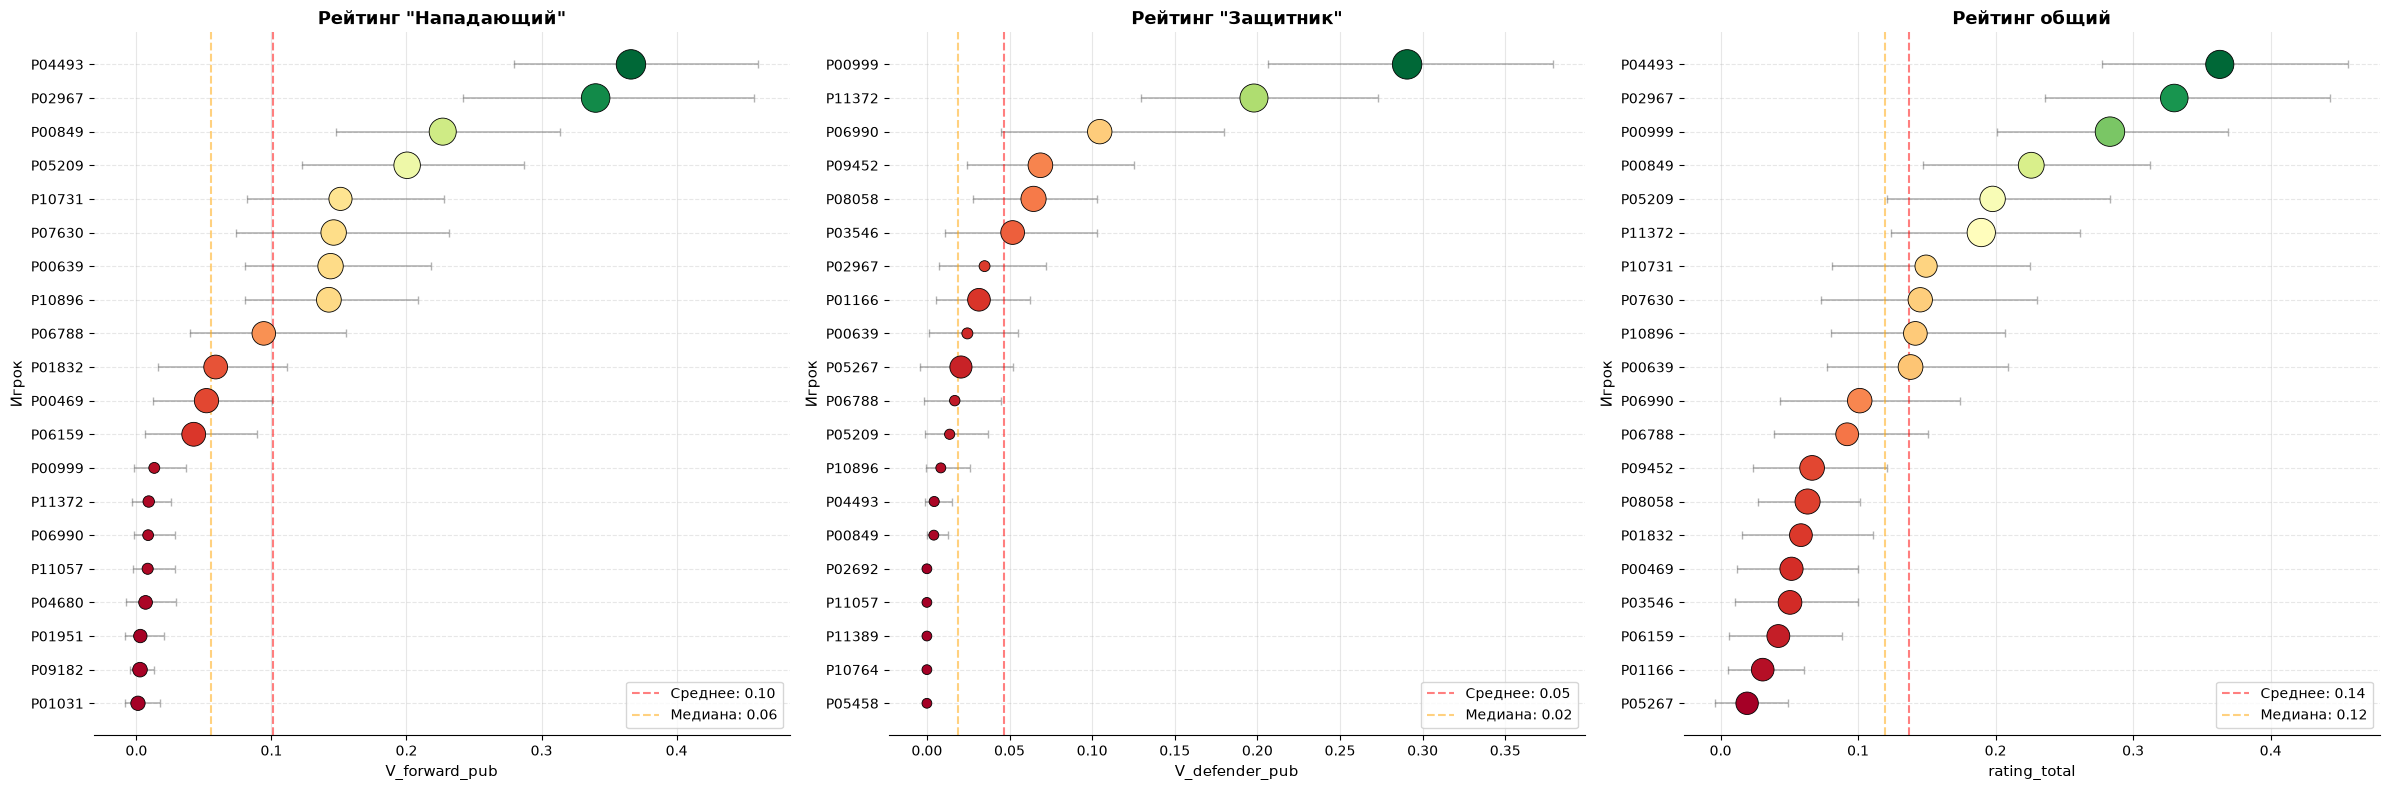

In [8]:
import matplotlib.pyplot as plt
from plotter import Plotter

plotter = Plotter()

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
plotter.plot_player_ratings(axes[0], ratings, 'V_forward_pub',  toi_col='p_dur_forward_s', 	error_low_col='V_forward_pub_ci_low', 	error_high_col='V_forward_pub_ci_high', top_n=20, title='Рейтинг "Нападающий"')
plotter.plot_player_ratings(axes[1], ratings, 'V_defender_pub', toi_col='p_dur_defender_s',	error_low_col='V_defender_pub_ci_low', 	error_high_col='V_defender_pub_ci_high',top_n=20, title='Рейтинг "Защитник"')
plotter.plot_player_ratings(axes[2], ratings, 'rating_total',   toi_col='p_dur_total',     	error_low_col='rating_total_ci_low', 		error_high_col='rating_total_ci_high', 	top_n=20, title='Рейтинг общий')

fig.show()
fig.savefig(f'{prefix}/plot_1.png')